# Push-Up Pose Estimation with MediaPipe
The goal is to prepare clean landmark data for push-up posture analysis.
Output used by notebook 02_feature_engineering_mediapipe.

In [1]:
import os
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import mediapipe as mp

In [2]:
from pathlib import Path

# Notebook is in posture_checker/notebooks
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
VIDEOS_DIR = RAW_DIR / "videos"

CORRECT_DIR = VIDEOS_DIR / "correct"
INCORRECT_DIR = VIDEOS_DIR / "incorrect"

INTERIM_DIR = DATA_DIR / "interim"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

LANDMARKS_JSON_DIR = INTERIM_DIR / "landmarks_json"
LANDMARKS_JSON_DIR.mkdir(parents=True, exist_ok=True)

LANDMARKS_CSV_PATH = INTERIM_DIR / "pose_landmarks_pushups.csv"

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Videos dir:", VIDEOS_DIR)
print("Correct videos:", CORRECT_DIR)
print("Incorrect videos:", INCORRECT_DIR)
print("Output CSV:", LANDMARKS_CSV_PATH)
print("Correct dir exists:", CORRECT_DIR.exists())
print("Incorrect dir exists:", INCORRECT_DIR.exists())

Current working directory: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\notebooks
Project root: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker
Videos dir: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\raw\videos
Correct videos: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\raw\videos\correct
Incorrect videos: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\raw\videos\incorrect
Output CSV: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\interim\pose_landmarks_pushups.csv
Correct dir exists: True
Incorrect dir exists: True


In [3]:
def list_video_files(folder: Path, extensions=(".mp4", ".mov", ".avi", ".mkv")):
    if not folder.exists():
        return []
    files = [f for f in folder.iterdir() if f.is_file() and f.suffix.lower() in extensions]
    return sorted(files)

correct_videos = list_video_files(CORRECT_DIR)
incorrect_videos = list_video_files(INCORRECT_DIR)

print(f"Found {len(correct_videos)} correct videos")
for f in correct_videos:
    print("  ", f.name)

print(f"\nFound {len(incorrect_videos)} incorrect videos")
for f in incorrect_videos:
    print("  ", f.name)

Found 50 correct videos
   Copy of push up 1.mp4
   Copy of push up 100.mp4
   Copy of push up 101.mp4
   Copy of push up 102.mp4
   Copy of push up 113.mp4
   Copy of push up 114.mp4
   Copy of push up 115.mp4
   Copy of push up 116.mp4
   Copy of push up 127.mp4
   Copy of push up 129.mp4
   Copy of push up 131.mp4
   Copy of push up 132.mp4
   Copy of push up 133.mp4
   Copy of push up 134.mp4
   Copy of push up 135.mp4
   Copy of push up 136.mp4
   Copy of push up 137.mp4
   Copy of push up 138.mp4
   Copy of push up 140.mp4
   Copy of push up 141.mp4
   Copy of push up 142.mp4
   Copy of push up 144.mp4
   Copy of push up 146.mp4
   Copy of push up 147.mp4
   Copy of push up 148.mp4
   Copy of push up 162.mp4
   Copy of push up 163.mp4
   Copy of push up 164.mp4
   Copy of push up 165.mp4
   Copy of push up 173.mp4
   Copy of push up 174.mp4
   Copy of push up 175.mp4
   Copy of push up 177.mp4
   Copy of push up 178.mp4
   Copy of push up 186.mp4
   Copy of push up 187.mp4
   Cop

In [4]:
def validate_video(video_path: Path, max_test_frames: int = 5):
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        return {
            "file": video_path.name,
            "readable": False,
            "frame_count": 0,
            "fps": None,
            "width": None,
            "height": None,
            "tested_frames": 0
        }
    
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    tested = 0
    readable = True
    
    for _ in range(max_test_frames):
        ret, frame = cap.read()
        if not ret or frame is None:
            readable = False
            break
        tested += 1
    
    cap.release()
    
    return {
        "file": video_path.name,
        "readable": readable,
        "frame_count": frame_count,
        "fps": fps,
        "width": width,
        "height": height,
        "tested_frames": tested
    }

all_videos = correct_videos + incorrect_videos
validation_results = [validate_video(video) for video in all_videos]
validation_df = pd.DataFrame(validation_results)

validation_df

,file,readable,frame_count,fps,width,height,tested_frames
0,Copy of push up 1.mp4,True,61,25.0,640,360,5
1,Copy of push up 100.mp4,True,124,25.0,640,360,5
2,Copy of push up 101.mp4,True,77,25.0,640,360,5
3,Copy of push up 102.mp4,True,83,25.0,640,360,5
4,Copy of push up 113.mp4,True,77,25.0,640,360,5
...,...,...,...,...,...,...,...
95,Copy of push up 55.mp4,True,113,25.0,640,360,5
96,Copy of push up 56.mp4,True,107,25.0,640,360,5
97,Copy of push up 57.mp4,True,75,25.0,640,360,5
98,Copy of push up 58.mp4,True,84,25.0,640,360,5


In [5]:
bad_videos = validation_df[validation_df["readable"] == False]

if len(bad_videos) == 0:
    print("All videos are readable.")
else:
    print("Unreadable or problematic videos found:")
    display(bad_videos)

All videos are readable.


In [6]:
import mediapipe as mp
print(mp.__file__)
print(dir(mp))

C:\Users\sebas\anaconda3\envs\dne\Lib\site-packages\mediapipe\__init__.py
['CalculatorGraph', 'GraphInputStreamAddMode', 'Image', 'ImageFormat', 'ImageFrame', 'Matrix', 'Packet', 'Timestamp', 'ValidatedGraphConfig', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'calculators', 'model_ckpt_util', 'packet_creator', 'packet_getter', 'resource_util', 'solutions', 'tasks']


In [7]:
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

POSE_LANDMARK_NAMES = [landmark.name for landmark in mp_pose.PoseLandmark]
NUM_LANDMARKS = len(POSE_LANDMARK_NAMES)

print(f"Number of pose landmarks: {NUM_LANDMARKS}")
print(POSE_LANDMARK_NAMES)

Number of pose landmarks: 33
['NOSE', 'LEFT_EYE_INNER', 'LEFT_EYE', 'LEFT_EYE_OUTER', 'RIGHT_EYE_INNER', 'RIGHT_EYE', 'RIGHT_EYE_OUTER', 'LEFT_EAR', 'RIGHT_EAR', 'MOUTH_LEFT', 'MOUTH_RIGHT', 'LEFT_SHOULDER', 'RIGHT_SHOULDER', 'LEFT_ELBOW', 'RIGHT_ELBOW', 'LEFT_WRIST', 'RIGHT_WRIST', 'LEFT_PINKY', 'RIGHT_PINKY', 'LEFT_INDEX', 'RIGHT_INDEX', 'LEFT_THUMB', 'RIGHT_THUMB', 'LEFT_HIP', 'RIGHT_HIP', 'LEFT_KNEE', 'RIGHT_KNEE', 'LEFT_ANKLE', 'RIGHT_ANKLE', 'LEFT_HEEL', 'RIGHT_HEEL', 'LEFT_FOOT_INDEX', 'RIGHT_FOOT_INDEX']


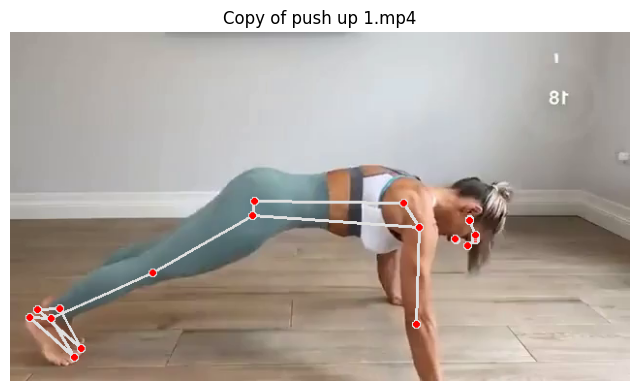

In [8]:
def preview_pose_on_first_frame(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    ret, frame = cap.read()
    cap.release()
    
    if not ret or frame is None:
        print(f"Could not read first frame from {video_path.name}")
        return
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    with mp_pose.Pose(
        static_image_mode=True,
        model_complexity=1,
        enable_segmentation=False,
        min_detection_confidence=0.5
    ) as pose:
        results = pose.process(frame_rgb)
    
    annotated = frame.copy()
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            annotated,
            results.pose_landmarks,
            mp_pose.POSE_CONNECTIONS
        )
    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(video_path.name)
    plt.axis("off")
    plt.show()


# Test preview
if len(correct_videos) > 0:
    preview_pose_on_first_frame(correct_videos[0])

In [9]:
def extract_landmarks_from_results(results):
    row = {}
    
    if results.pose_landmarks is None:
        for name in POSE_LANDMARK_NAMES:
            row[f"{name.lower()}_x"] = np.nan
            row[f"{name.lower()}_y"] = np.nan
            row[f"{name.lower()}_z"] = np.nan
            row[f"{name.lower()}_visibility"] = np.nan
        row["pose_detected"] = 0
        return row
    
    landmarks = results.pose_landmarks.landmark
    
    for idx, name in enumerate(POSE_LANDMARK_NAMES):
        lm = landmarks[idx]
        row[f"{name.lower()}_x"] = lm.x
        row[f"{name.lower()}_y"] = lm.y
        row[f"{name.lower()}_z"] = lm.z
        row[f"{name.lower()}_visibility"] = lm.visibility
    
    row["pose_detected"] = 1
    return row

In [10]:
def process_video(video_path: Path, label: str, save_json: bool = True):
    cap = cv2.VideoCapture(str(video_path))
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    rows = []
    json_frames = []
    
    with mp_pose.Pose(
        static_image_mode=False,
        model_complexity=1,
        smooth_landmarks=True,
        enable_segmentation=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as pose:
        
        frame_idx = 0
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = pose.process(frame_rgb)
            
            row = {
                "video_name": video_path.name,
                "video_stem": video_path.stem,
                "label": label,
                "frame_index": frame_idx,
                "fps": fps,
                "timestamp_sec": frame_idx / fps if fps and fps > 0 else np.nan
            }
            
            row.update(extract_landmarks_from_results(results))
            rows.append(row)
            
            if save_json:
                json_frames.append(row)
            
            frame_idx += 1
    
    cap.release()
    
    if save_json:
        output_json_path = LANDMARKS_JSON_DIR / f"{video_path.stem}.json"
        with open(output_json_path, "w", encoding="utf-8") as f:
            json.dump(json_frames, f, indent=2)
    
    return rows

In [11]:
all_rows = []

for video_path in tqdm(correct_videos, desc="Processing correct videos"):
    rows = process_video(video_path, label="correct", save_json=True)
    all_rows.extend(rows)

for video_path in tqdm(incorrect_videos, desc="Processing incorrect videos"):
    rows = process_video(video_path, label="incorrect", save_json=True)
    all_rows.extend(rows)

pose_df = pd.DataFrame(all_rows)

print("Processing complete.")
print("Shape:", pose_df.shape)
pose_df.head()

Processing incorrect videos: 100%|█████████████████████████████████████████████████████| 50/50 [03:48<00:00,  4.58s/it]


Processing complete.
Shape: (10928, 139)


,video_name,video_stem,label,frame_index,fps,timestamp_sec,nose_x,nose_y,nose_z,nose_visibility,...,right_heel_visibility,left_foot_index_x,left_foot_index_y,left_foot_index_z,left_foot_index_visibility,right_foot_index_x,right_foot_index_y,right_foot_index_z,right_foot_index_visibility,pose_detected
0,Copy of push up 1.mp4,Copy of push up 1,correct,0,25.0,0.00,0.737741,0.611303,0.014359,0.999858,...,0.987817,0.115150,0.906979,0.291378,0.866467,0.104528,0.931178,0.032273,0.987492,1
1,Copy of push up 1.mp4,Copy of push up 1,correct,1,25.0,0.04,0.724616,0.607699,0.011920,0.999796,...,0.986590,0.114344,0.906850,0.230542,0.847561,0.104248,0.931257,-0.039504,0.985982,1
2,Copy of push up 1.mp4,Copy of push up 1,correct,2,25.0,0.08,0.720977,0.606046,0.011736,0.999764,...,0.985962,0.113232,0.906629,0.224317,0.833872,0.103429,0.931365,-0.039549,0.985207,1
3,Copy of push up 1.mp4,Copy of push up 1,correct,3,25.0,0.12,0.721067,0.605006,0.013029,0.999734,...,0.985171,0.112770,0.905566,0.217476,0.818031,0.103047,0.931322,-0.051117,0.984212,1
4,Copy of push up 1.mp4,Copy of push up 1,correct,4,25.0,0.16,0.721958,0.604109,0.012018,0.999715,...,0.984401,0.109374,0.904433,0.199174,0.803506,0.101249,0.931254,-0.069340,0.983280,1


In [12]:
pose_df.to_csv(LANDMARKS_CSV_PATH, index=False)
print(f"Saved CSV to: {LANDMARKS_CSV_PATH}")

Saved CSV to: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\interim\pose_landmarks_pushups.csv


In [13]:
print("Number of videos:", pose_df["video_name"].nunique())
print("Labels:", pose_df["label"].value_counts().to_dict())
print("Pose detected ratio:", pose_df["pose_detected"].mean())

summary_df = (
    pose_df.groupby(["video_name", "label"])
    .agg(
        n_frames=("frame_index", "count"),
        pose_detection_rate=("pose_detected", "mean")
    )
    .reset_index()
)

summary_df

Number of videos: 100
Labels: {'incorrect': 6425, 'correct': 4503}
Pose detected ratio: 0.9999084919472914


,video_name,label,n_frames,pose_detection_rate
0,1.mp4,incorrect,290,1.0
1,10.mp4,incorrect,126,1.0
2,11.mp4,incorrect,83,1.0
3,12.mp4,incorrect,121,1.0
4,13.mp4,incorrect,121,1.0
...,...,...,...,...
95,Copy of push up 79.mp4,correct,45,1.0
96,Copy of push up 80.mp4,correct,157,1.0
97,Copy of push up 81.mp4,incorrect,93,1.0
98,Copy of push up 83.mp4,correct,63,1.0


In [14]:
nan_ratio = pose_df.isna().mean().sort_values(ascending=False)
nan_ratio.head(20)

left_wrist_visibility     0.000092
left_index_y              0.000092
right_thumb_visibility    0.000092
right_thumb_z             0.000092
right_thumb_y             0.000092
right_thumb_x             0.000092
left_thumb_visibility     0.000092
left_thumb_z              0.000092
left_thumb_y              0.000092
left_thumb_x              0.000092
right_index_visibility    0.000092
right_index_z             0.000092
right_index_y             0.000092
right_index_x             0.000092
left_index_visibility     0.000092
left_index_z              0.000092
left_index_x              0.000092
left_foot_index_z         0.000092
right_pinky_visibility    0.000092
right_pinky_z             0.000092
dtype: float64